# Getting started with MOFA-FLEX

MOFA-FLEX is a framework for factor analysis of multimodal data, with a focus on single-cell omics, representing an observed data matrix $\mat{Y}$ as a sum matrices $\mat{X}_i$, each of which is a product of a low-rank factor matrix $\mat{Z}_i$ and a low-rank weight matrix $\mat{W}_i$: $\mat{Y} \approx \sum_{i=1}^T\mat{Z}_i \mat{W}_i$.
In the simplest and most common case, there is only one additive term, i.e. $T = 1$.
In this case, MOFA-FLEX is essentially a synthesis of MOFA{cite:p}`pmid29925568,pmid32393329`, MEFISTO{cite:p}`pmid35027765`, MuVI{cite:p}`pmlr-v206-qoku23a`, nonnegative matrix factorization, and NSF{cite:p}`pmid36587187`.
It natively supports [MuData](https://mudata.readthedocs.io) and [AnnData](https://anndata.readthedocs.io) objects, integrating into the wider [scverse](https://scverse.org) ecosystem.

For this notebook, we will use the [pbmc3k dataset by 10x Genomics](https://www.10xgenomics.com/resources/datasets/pbmc-from-a-healthy-donor-granulocytes-removed-through-cell-sorting-3-k-1-standard-2-0-0), conveniently packaged in the `mudatasets` package.
The dataset contains 10 000 single cells profiled with the 10x multiome assay, capturing gene expression (scRNAseq) and chromatin accessibility (scATACseq).

In [1]:
import mudata as md
import mudatasets as mds
import muon as mu
import mofaflex as mfl
import scanpy as sc
from plotnine import *

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
theme_set(theme_bw())
md.set_options(display_style="html", display_html_expand=0);

In [3]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
mdata = mds.load("pbmc3k_multiome")

■ File filtered_feature_bc_matrix.h5 from pbmc3k_multiome has been found at /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5
■ Checksum is validated (md5) for filtered_feature_bc_matrix.h5
■ Loading filtered_feature_bc_matrix.h5...


/data/ilia/envs/famo/lib/python3.11/site-packages/mudatasets/core.py:203: UserWarning: Dataset is in the 10X .h5 format and can't be loaded as backed.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
/data/ilia/envs/famo/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


Added `interval` annotation for features from /home/kats/mudatasets/pbmc3k_multiome/filtered_feature_bc_matrix.h5


/data/ilia/envs/famo/lib/python3.11/site-packages/mudata/_core/mudata.py:599: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.


In [5]:
mdata.var_names_make_unique()
mdata

rna,bool,numpy.ndarray,1 columns
atac,bool,numpy.ndarray,1 columns


## Preprocessing

We first perform the basic preprocessing steps outlined in the [muon tutorial](inv:muon-tutorials#/single-cell-rna-atac/pbmc10k/1-gene-expression-processing.ipynb) to remove undetected genes and poor-quality cells.

In [6]:
rna = mdata["rna"]
rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    rna, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
mu.pp.filter_var(rna, "n_cells_by_counts", lambda x: x >= 3)
mu.pp.filter_obs(rna, "n_genes_by_counts", lambda x: (x >= 200) & (x < 5000))

mu.pp.filter_obs(rna, "total_counts", lambda x: x < 15000)
mu.pp.filter_obs(rna, "pct_counts_mt", lambda x: x < 20)

atac = mdata.mod["atac"]
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
mu.pp.filter_var(atac, "n_cells_by_counts", lambda x: x >= 10)
mu.pp.filter_obs(atac, "n_genes_by_counts", lambda x: (x >= 2000) & (x <= 15000))
mu.pp.filter_obs(atac, "total_counts", lambda x: (x >= 4000) & (x <= 40000))

We further normalize the data and determine highly variable genes.
MOFA-FLEX will automatically use only the highly variable genes for the analysis.

In [7]:
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)

mu.atac.pp.tfidf(atac, scale_factor=1e4)
sc.pp.normalize_per_cell(atac, counts_per_cell_after=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=0.5)

mdata.update()

In [8]:
mdata

MuData object with n_obs × n_vars = 2695 × 119335
  var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
  2 modalities
    rna:	2636 x 21256
      obs:	'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'
    atac:	2450 x 98079
      obs:	'n_genes_by_counts', 'total_counts', 'n_counts'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'log1p', 'hvg'

## Fitting a model

A MOFA-FLEX model is assembled from one or multiple additive terms, each of which takes parameters influencing the model.
A basic understanding of the [model](#modeldescription) is required to correctly set the parameters for a given dataset.

Since we have normalized the data in the previous section, we will use a Normal (Gaussian) likelihood.
In general, a negative binomial likelihood is more appropriate for unnormalized count data.
With default settings, MOFA-FLEX will plot the number of observations in each view and group.
This can be turned off by setting the `plot_data_overview` argument to [fit](#mofaflex.MOFAFLEX.fit) to `False`.
MOFA-FLEX will also automatically save the final model after training which can later be loaded with [](#mofaflex.MOFAFLEX.load).
The name of the saved file can be changed using the `save_path` argument to [fit](#mofaflex.MOFAFLEX.fit).

We will start with the simplest case of only one additive term.
There is currently one one type of additive term implemented: The [](#mofaflex.terms.MofaFlex) term, which is a product of two low-rank matrices $\mat{Z}\mat{W}$, as described above.
Additional term types may be added in the future.

In [9]:
model = mfl.terms.MofaFlex(n_factors=15)

This model corresponds to a standard MOFA model.
It is an instance of [](#mofaflex.MOFAFLEX).

WARNING	Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.


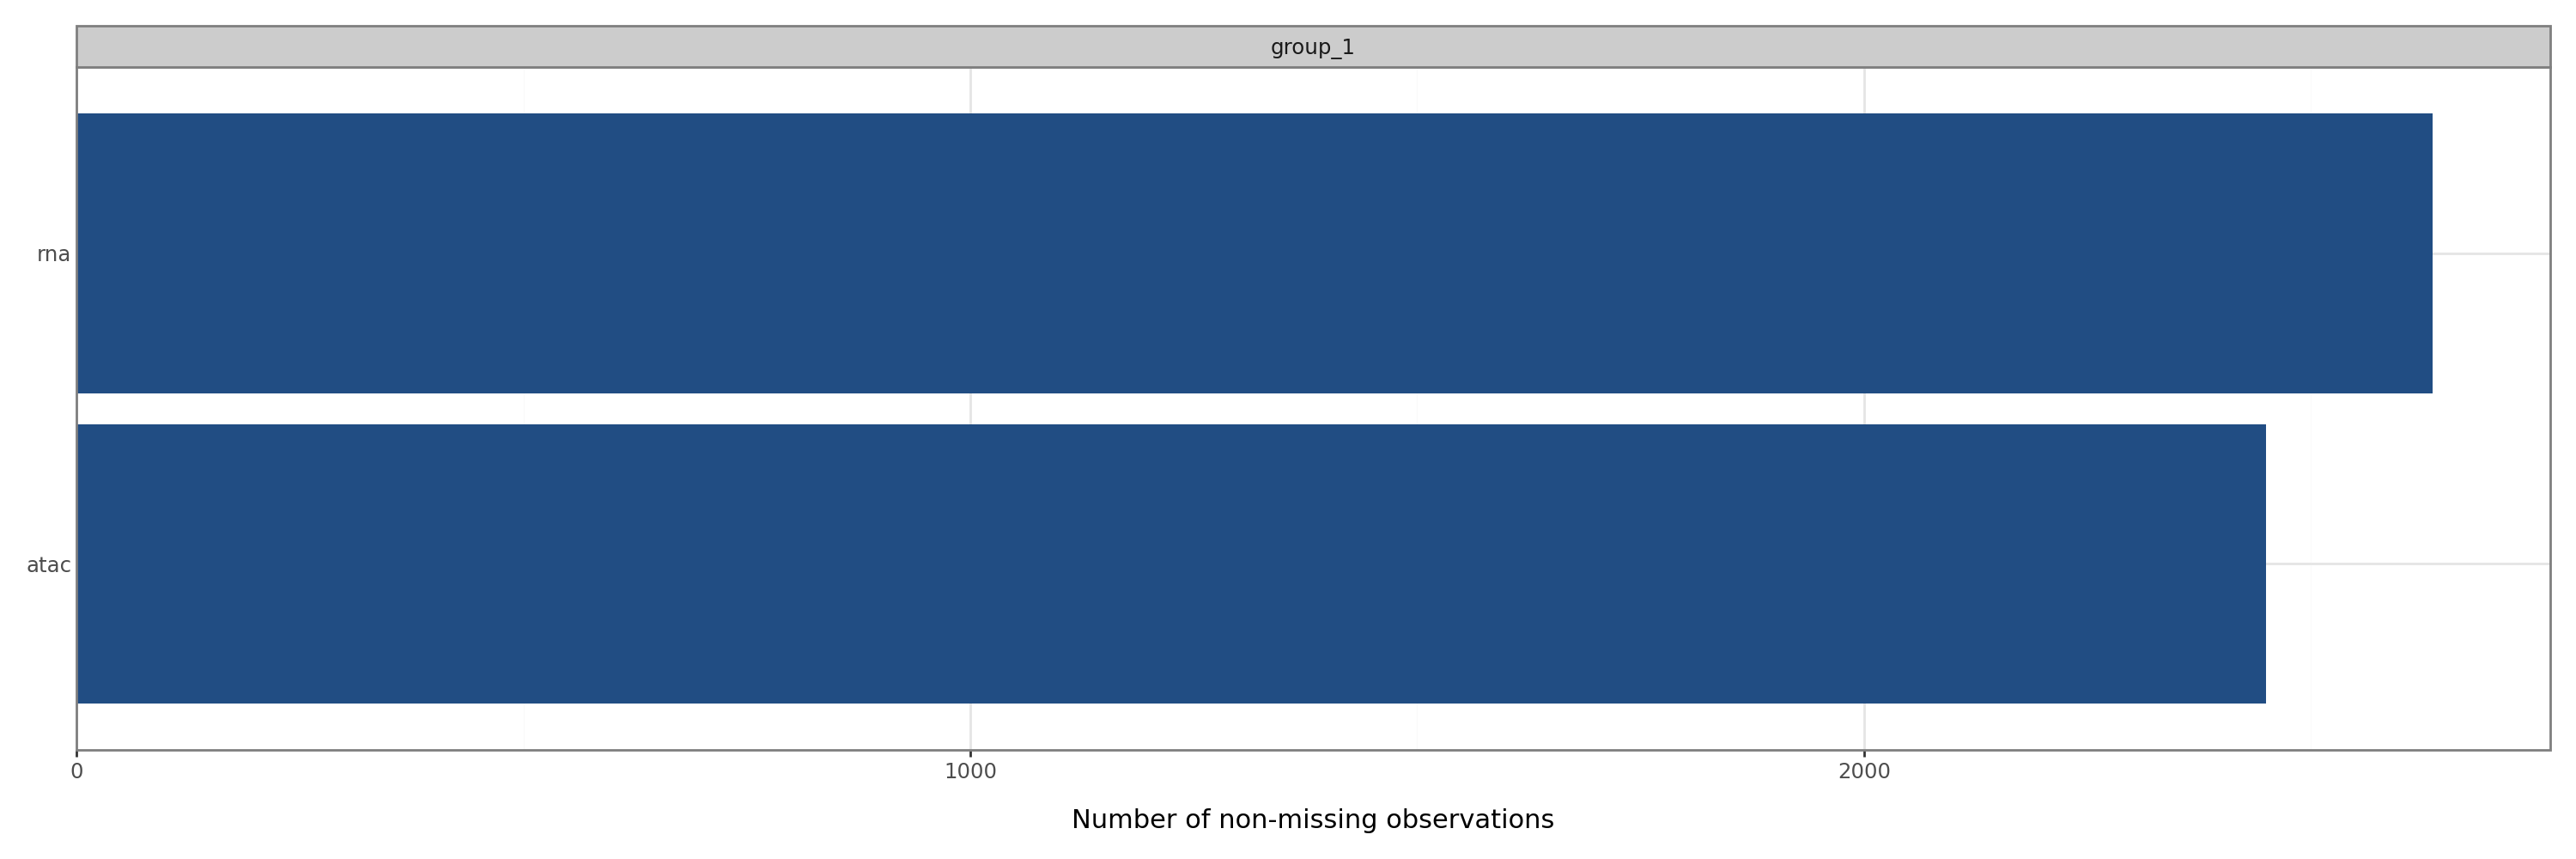

INFO	Initializing factors using 'random' method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 3
INFO	Training converged after 1759 epochs.
INFO	Saving results to mofaflex_20260120_120120.h5...


In [10]:
model.fit(mdata, likelihoods="Normal", batch_size=1000, seed=42)

We can plot the loss curve to get an overview of the training process:

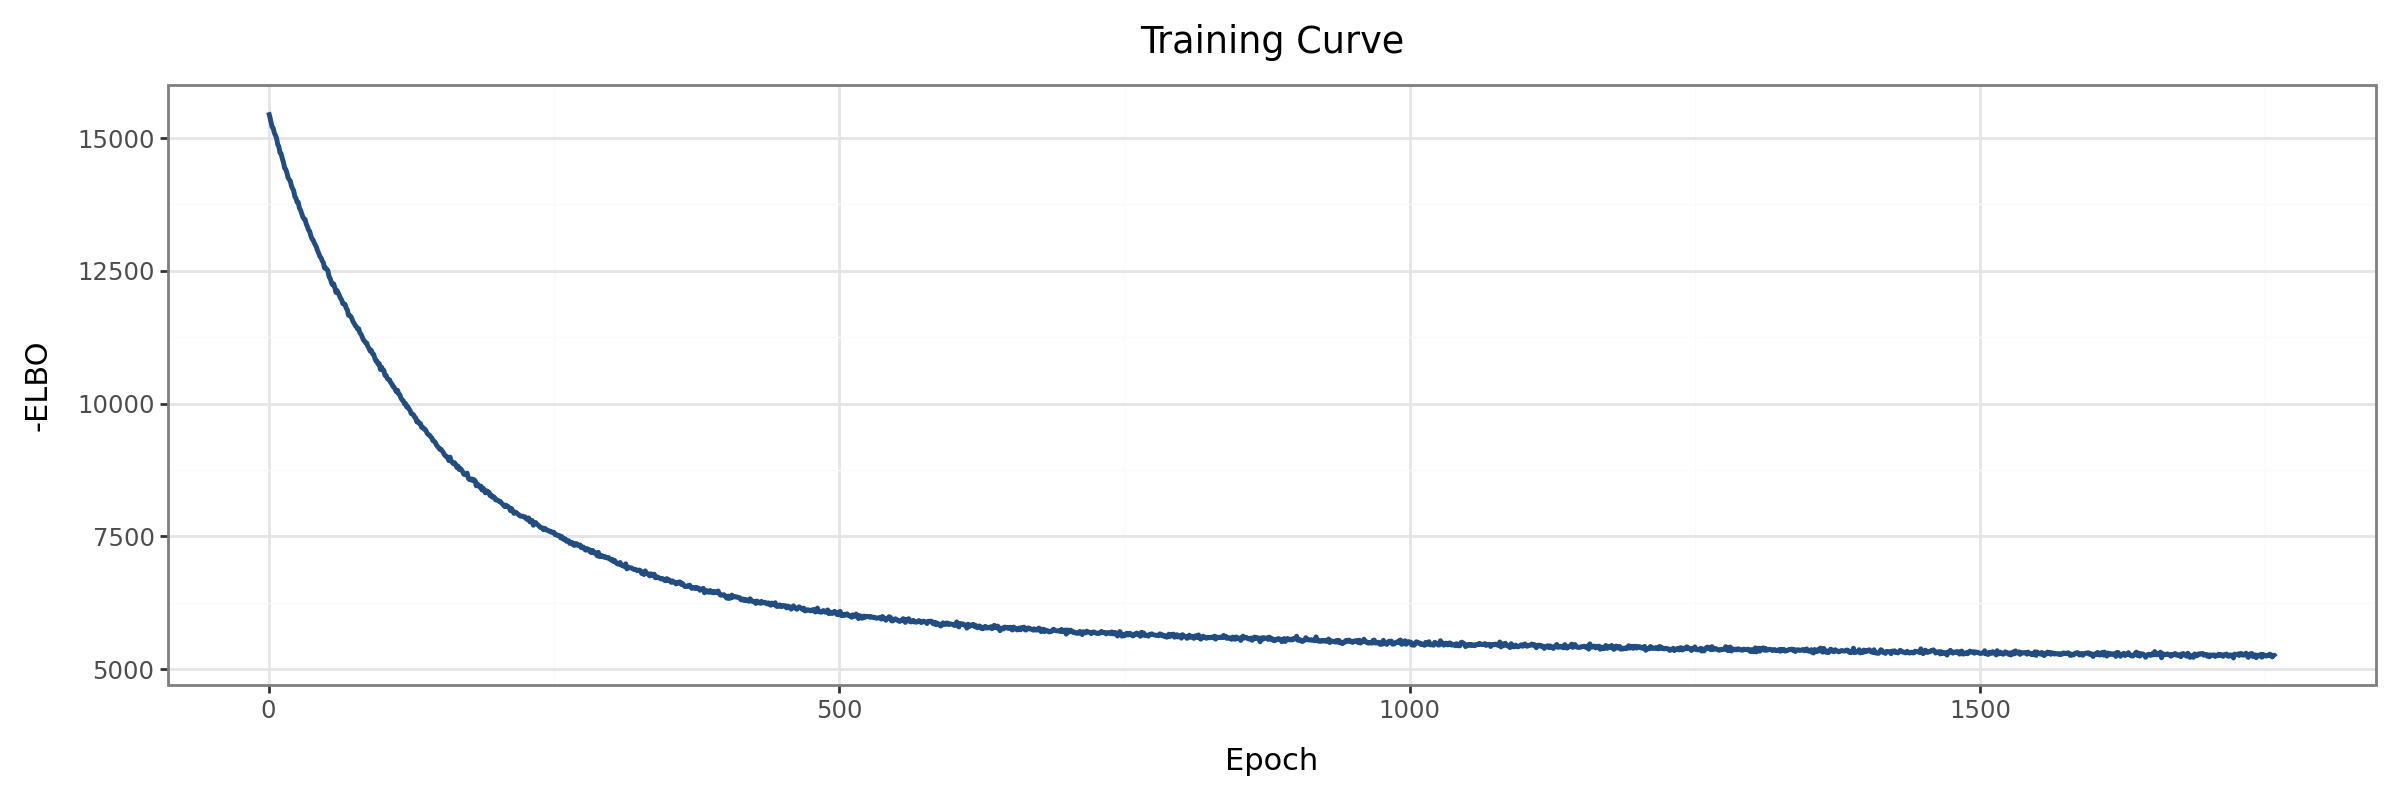

In [11]:
mfl.pl.training_curve(model)

## Analysing the model
The trained model can now be analysed to assess its quality and discover relevant biology.
Most relevant information is contained in the addtive terms themselves, as can be seen from the [API documentation](#mofaflex.terms.MofaFlex).
Because having only one term in the model is so common, this case is handled specially: The [](#mofaflex.MOFAFLEX) object forwards requests for any attributes that it doesn't know about to its only term.
We can therefore largely ignore anything related to additive terms and simply pass the [](#mofaflex.MOFAFLEX) object to any downstream analysis function.

First, we plot the correlations between factors, which should be as low as possible: We want factors to be uncorrelated, as each factor should capture a different aspect of the data.

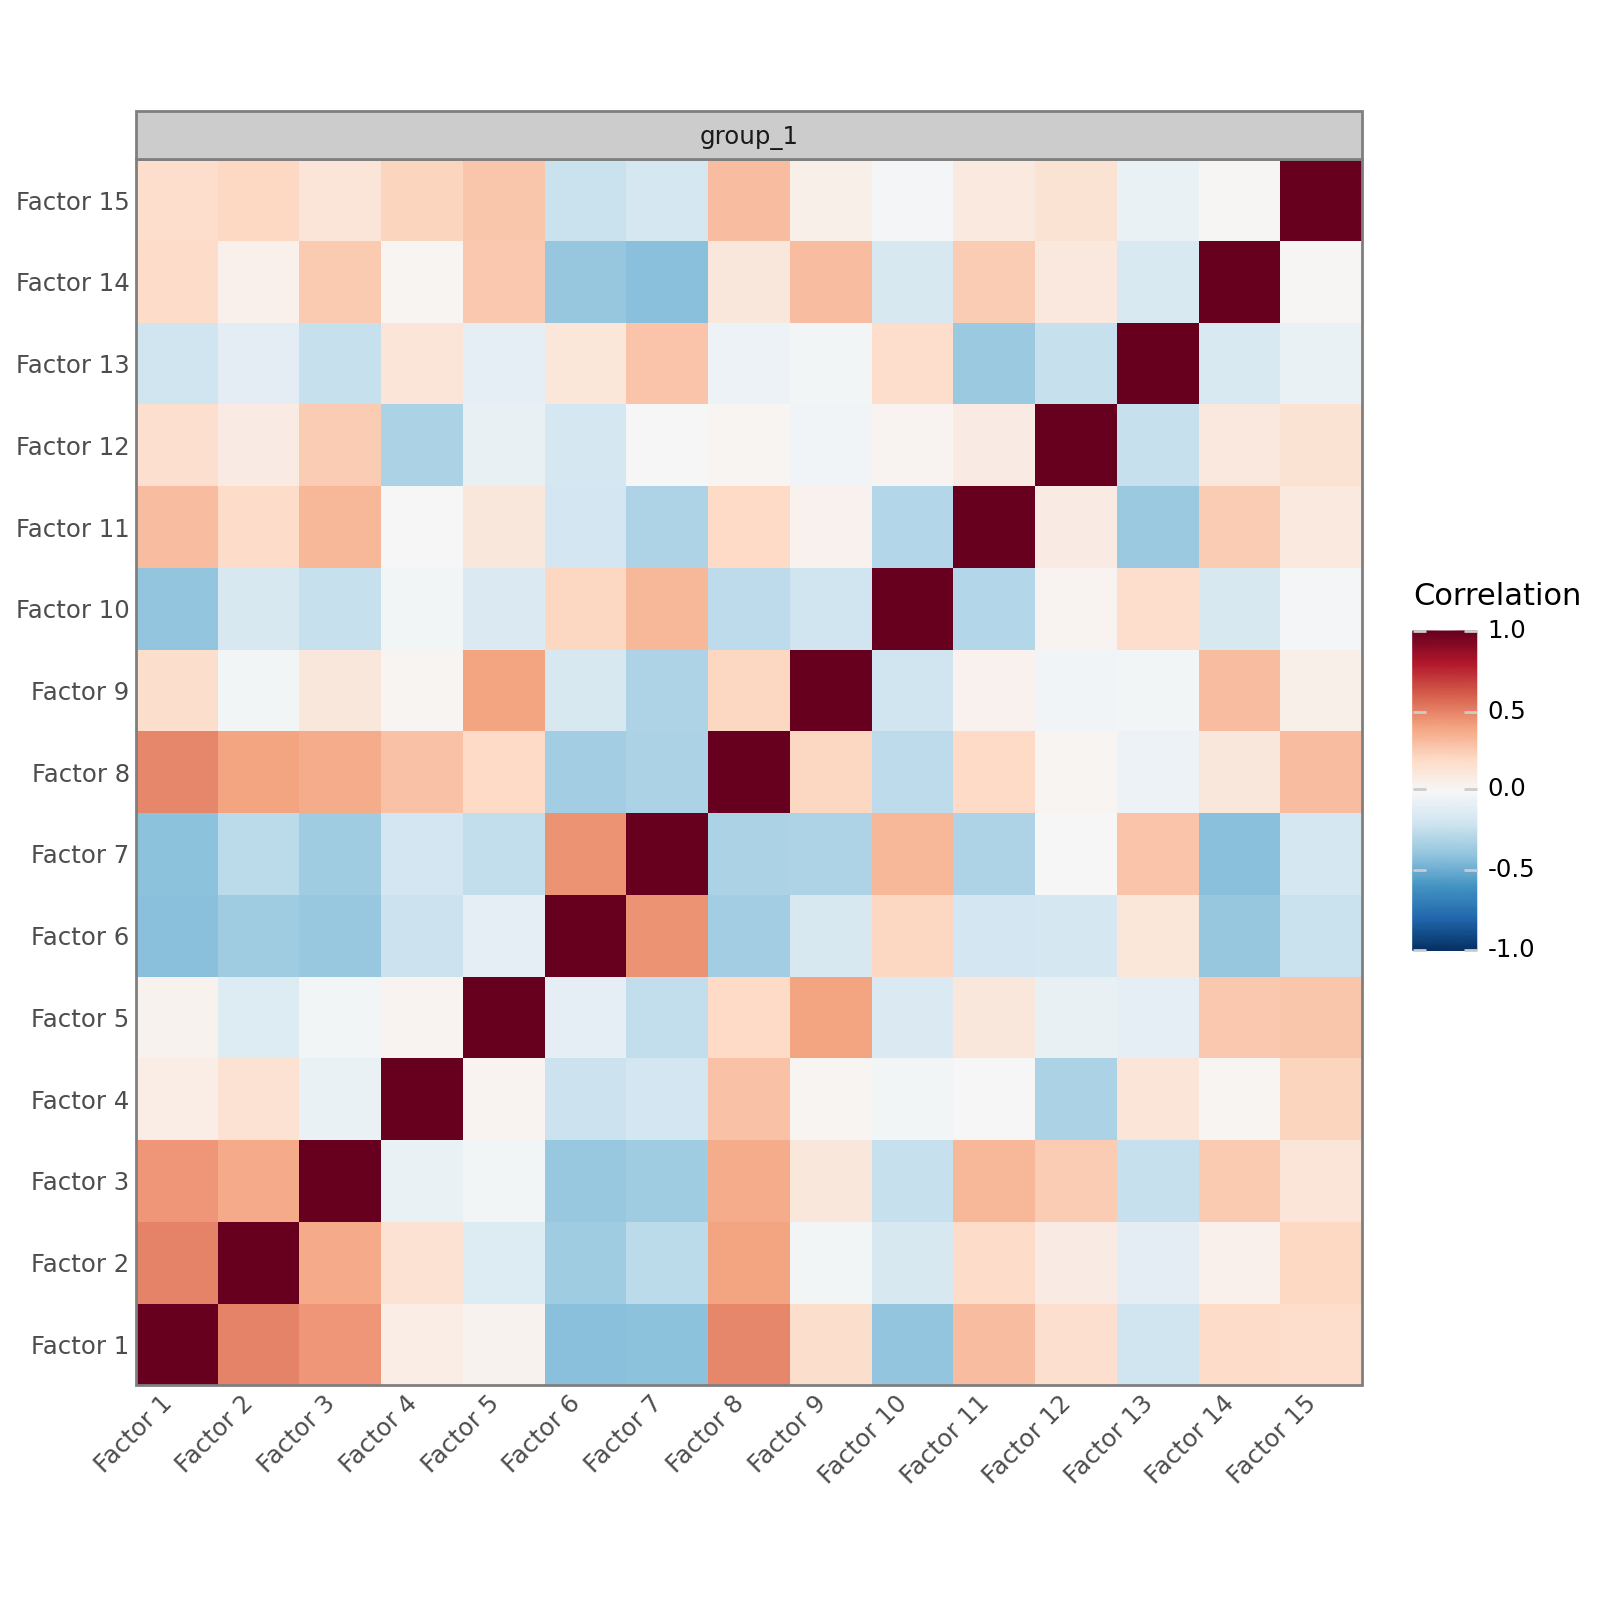

In [12]:
mfl.pl.factor_correlation(model)

This is not ideal, but good enough for a first look at the data.
We can now plot the fraction of variance in the data explained by each factor to determine the most important factors.
Note that for non-Normal likelihoods, these values are approximate.

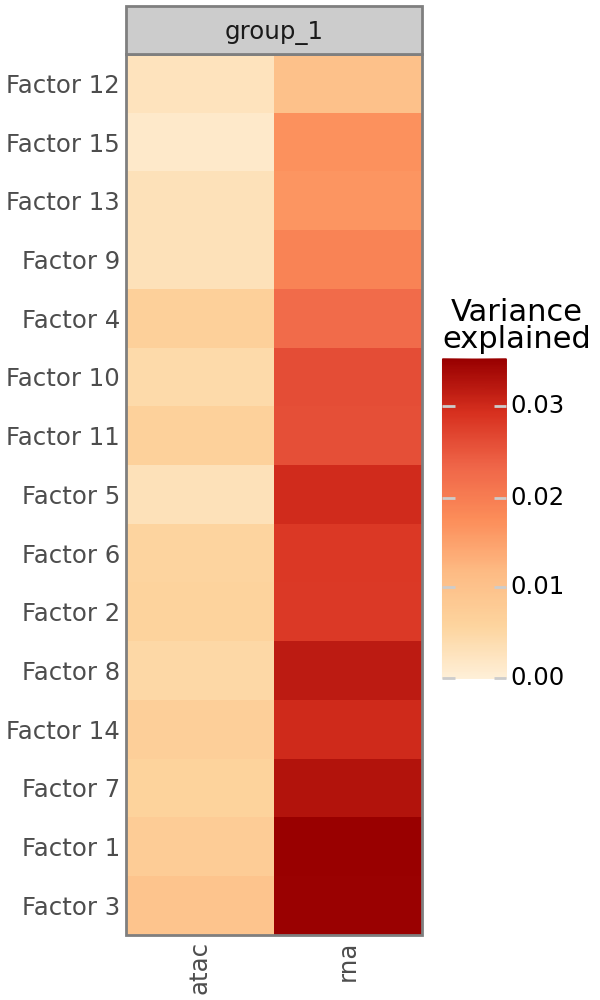

In [13]:
mfl.pl.variance_explained(model)

We can plot the most important genes per factor to get an idea of what each factor represents.
This plot aggregates over all views.

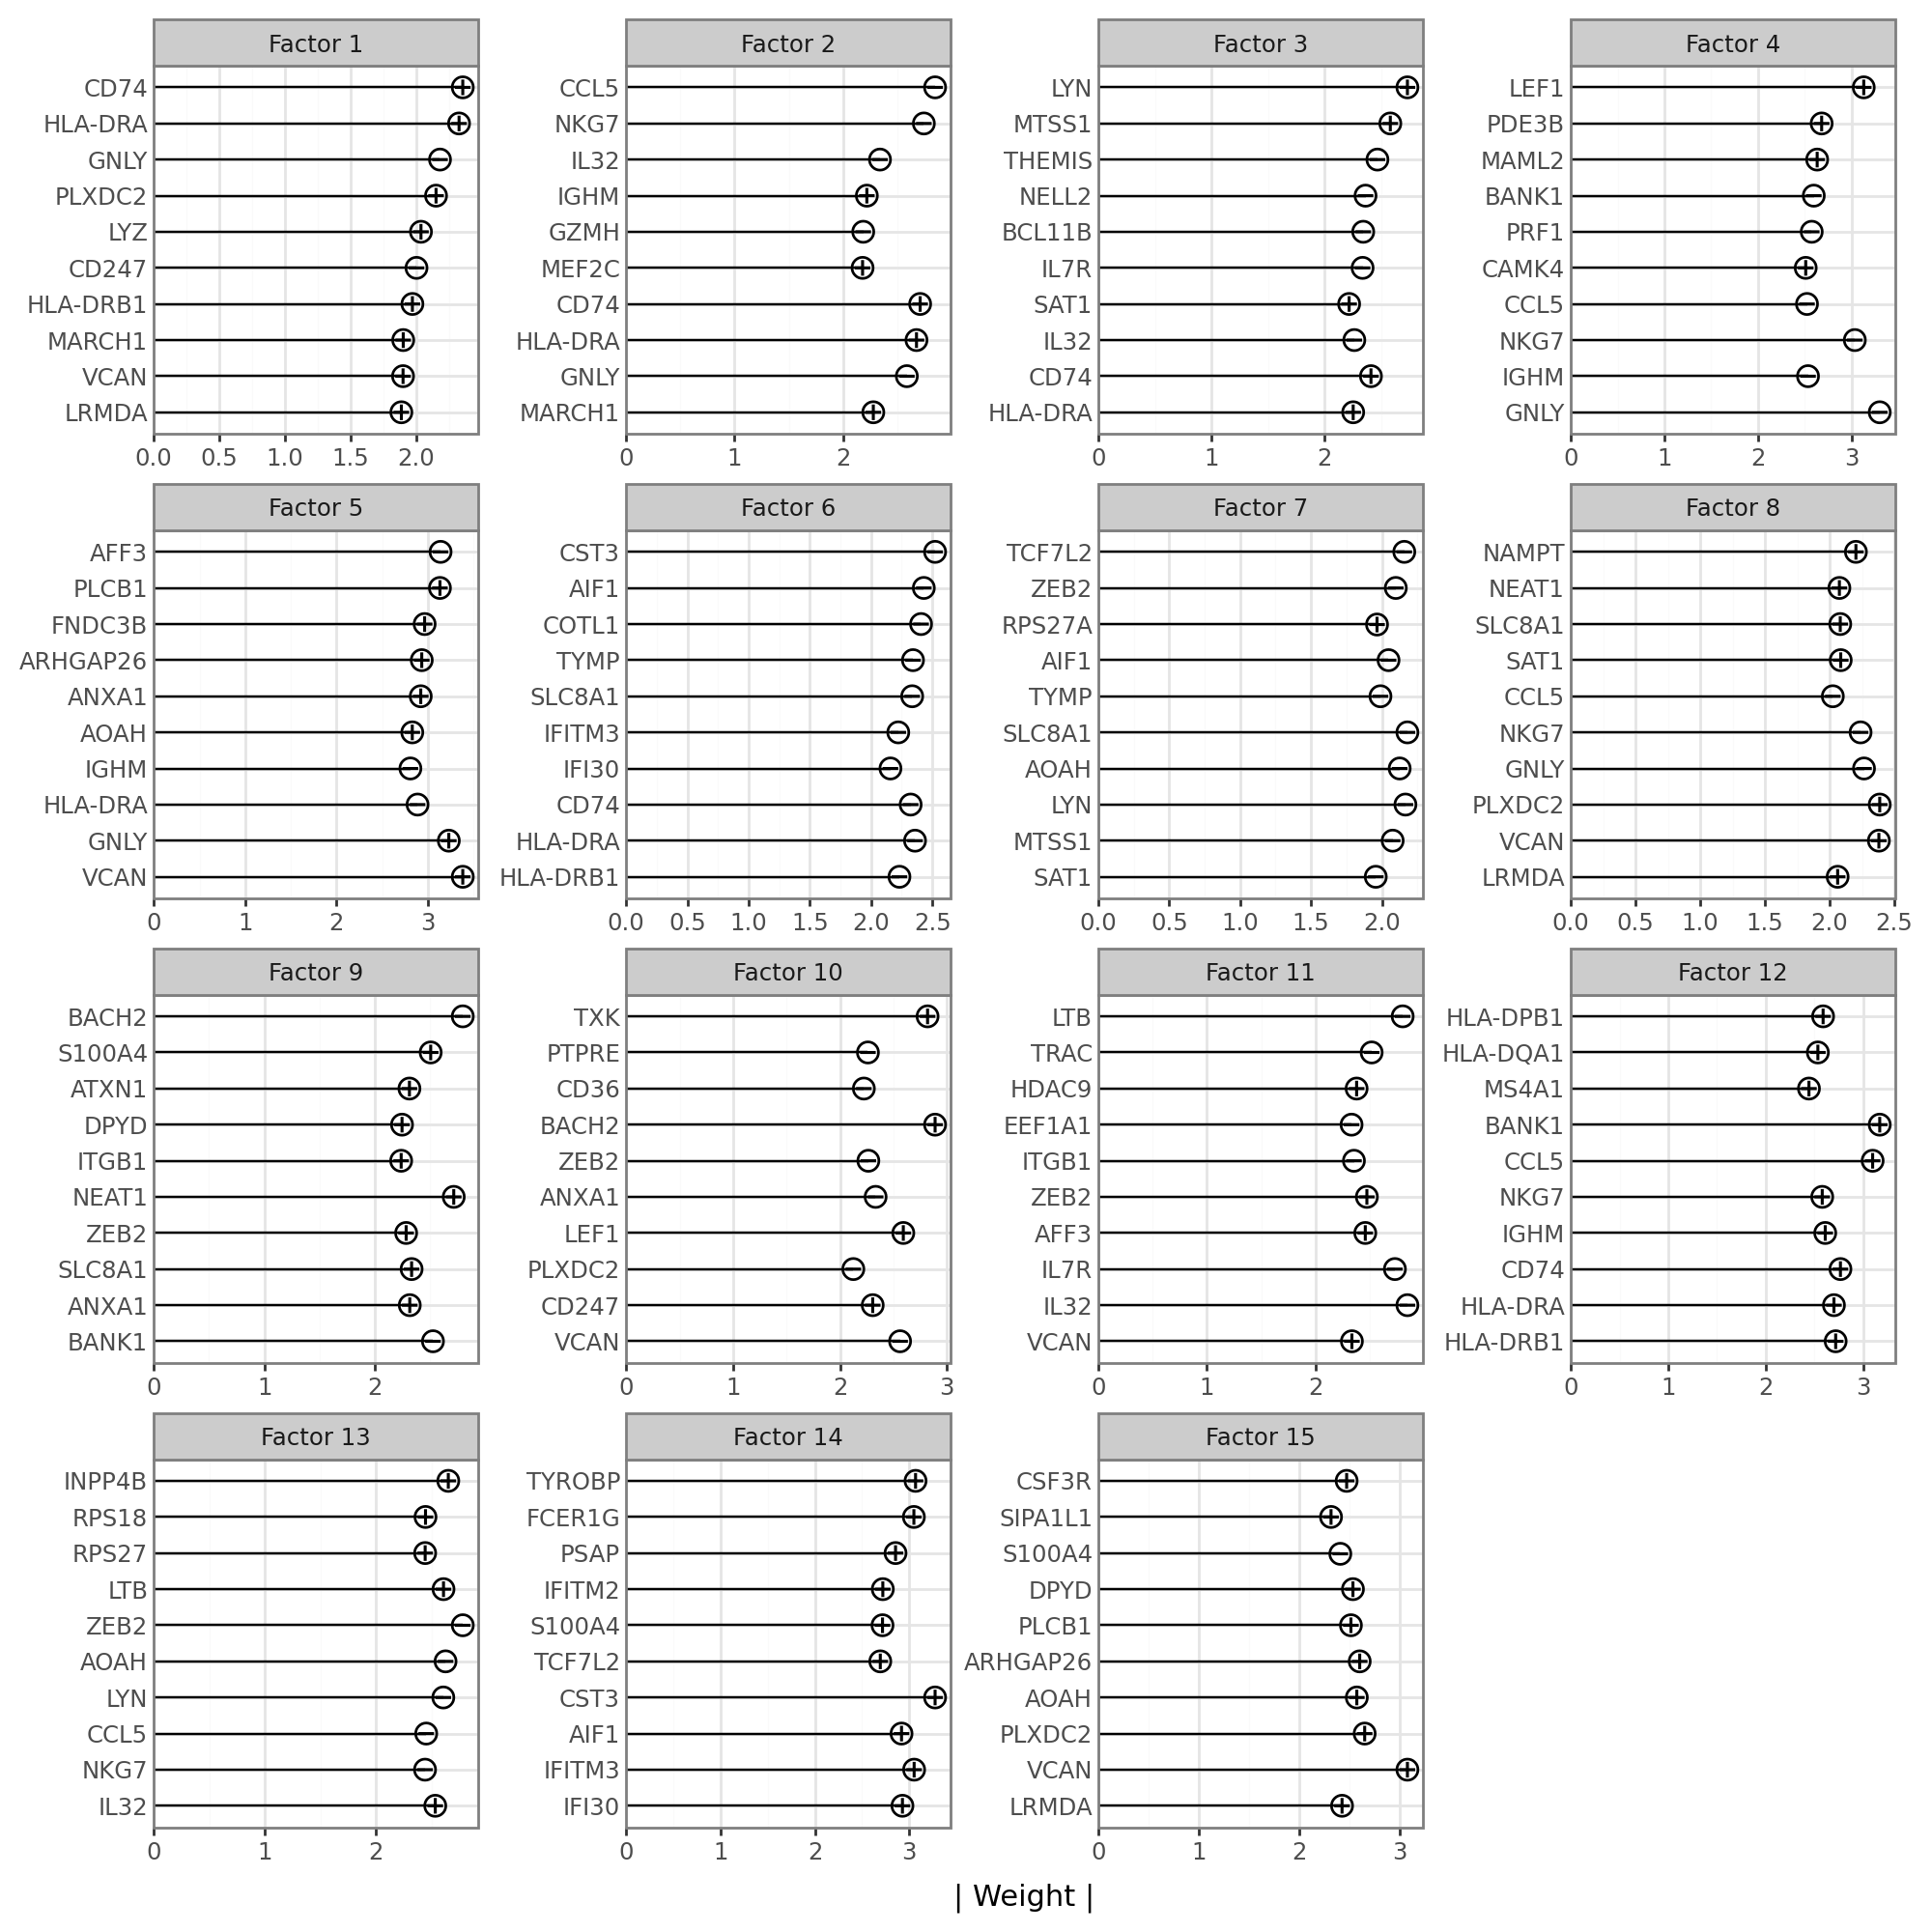

In [14]:
mfl.pl.top_weights(model, figsize=(10, 10))

It appears that the most important features are all from the RNA dataset.
We can use a different plotting function to get the top weights individually for each view.

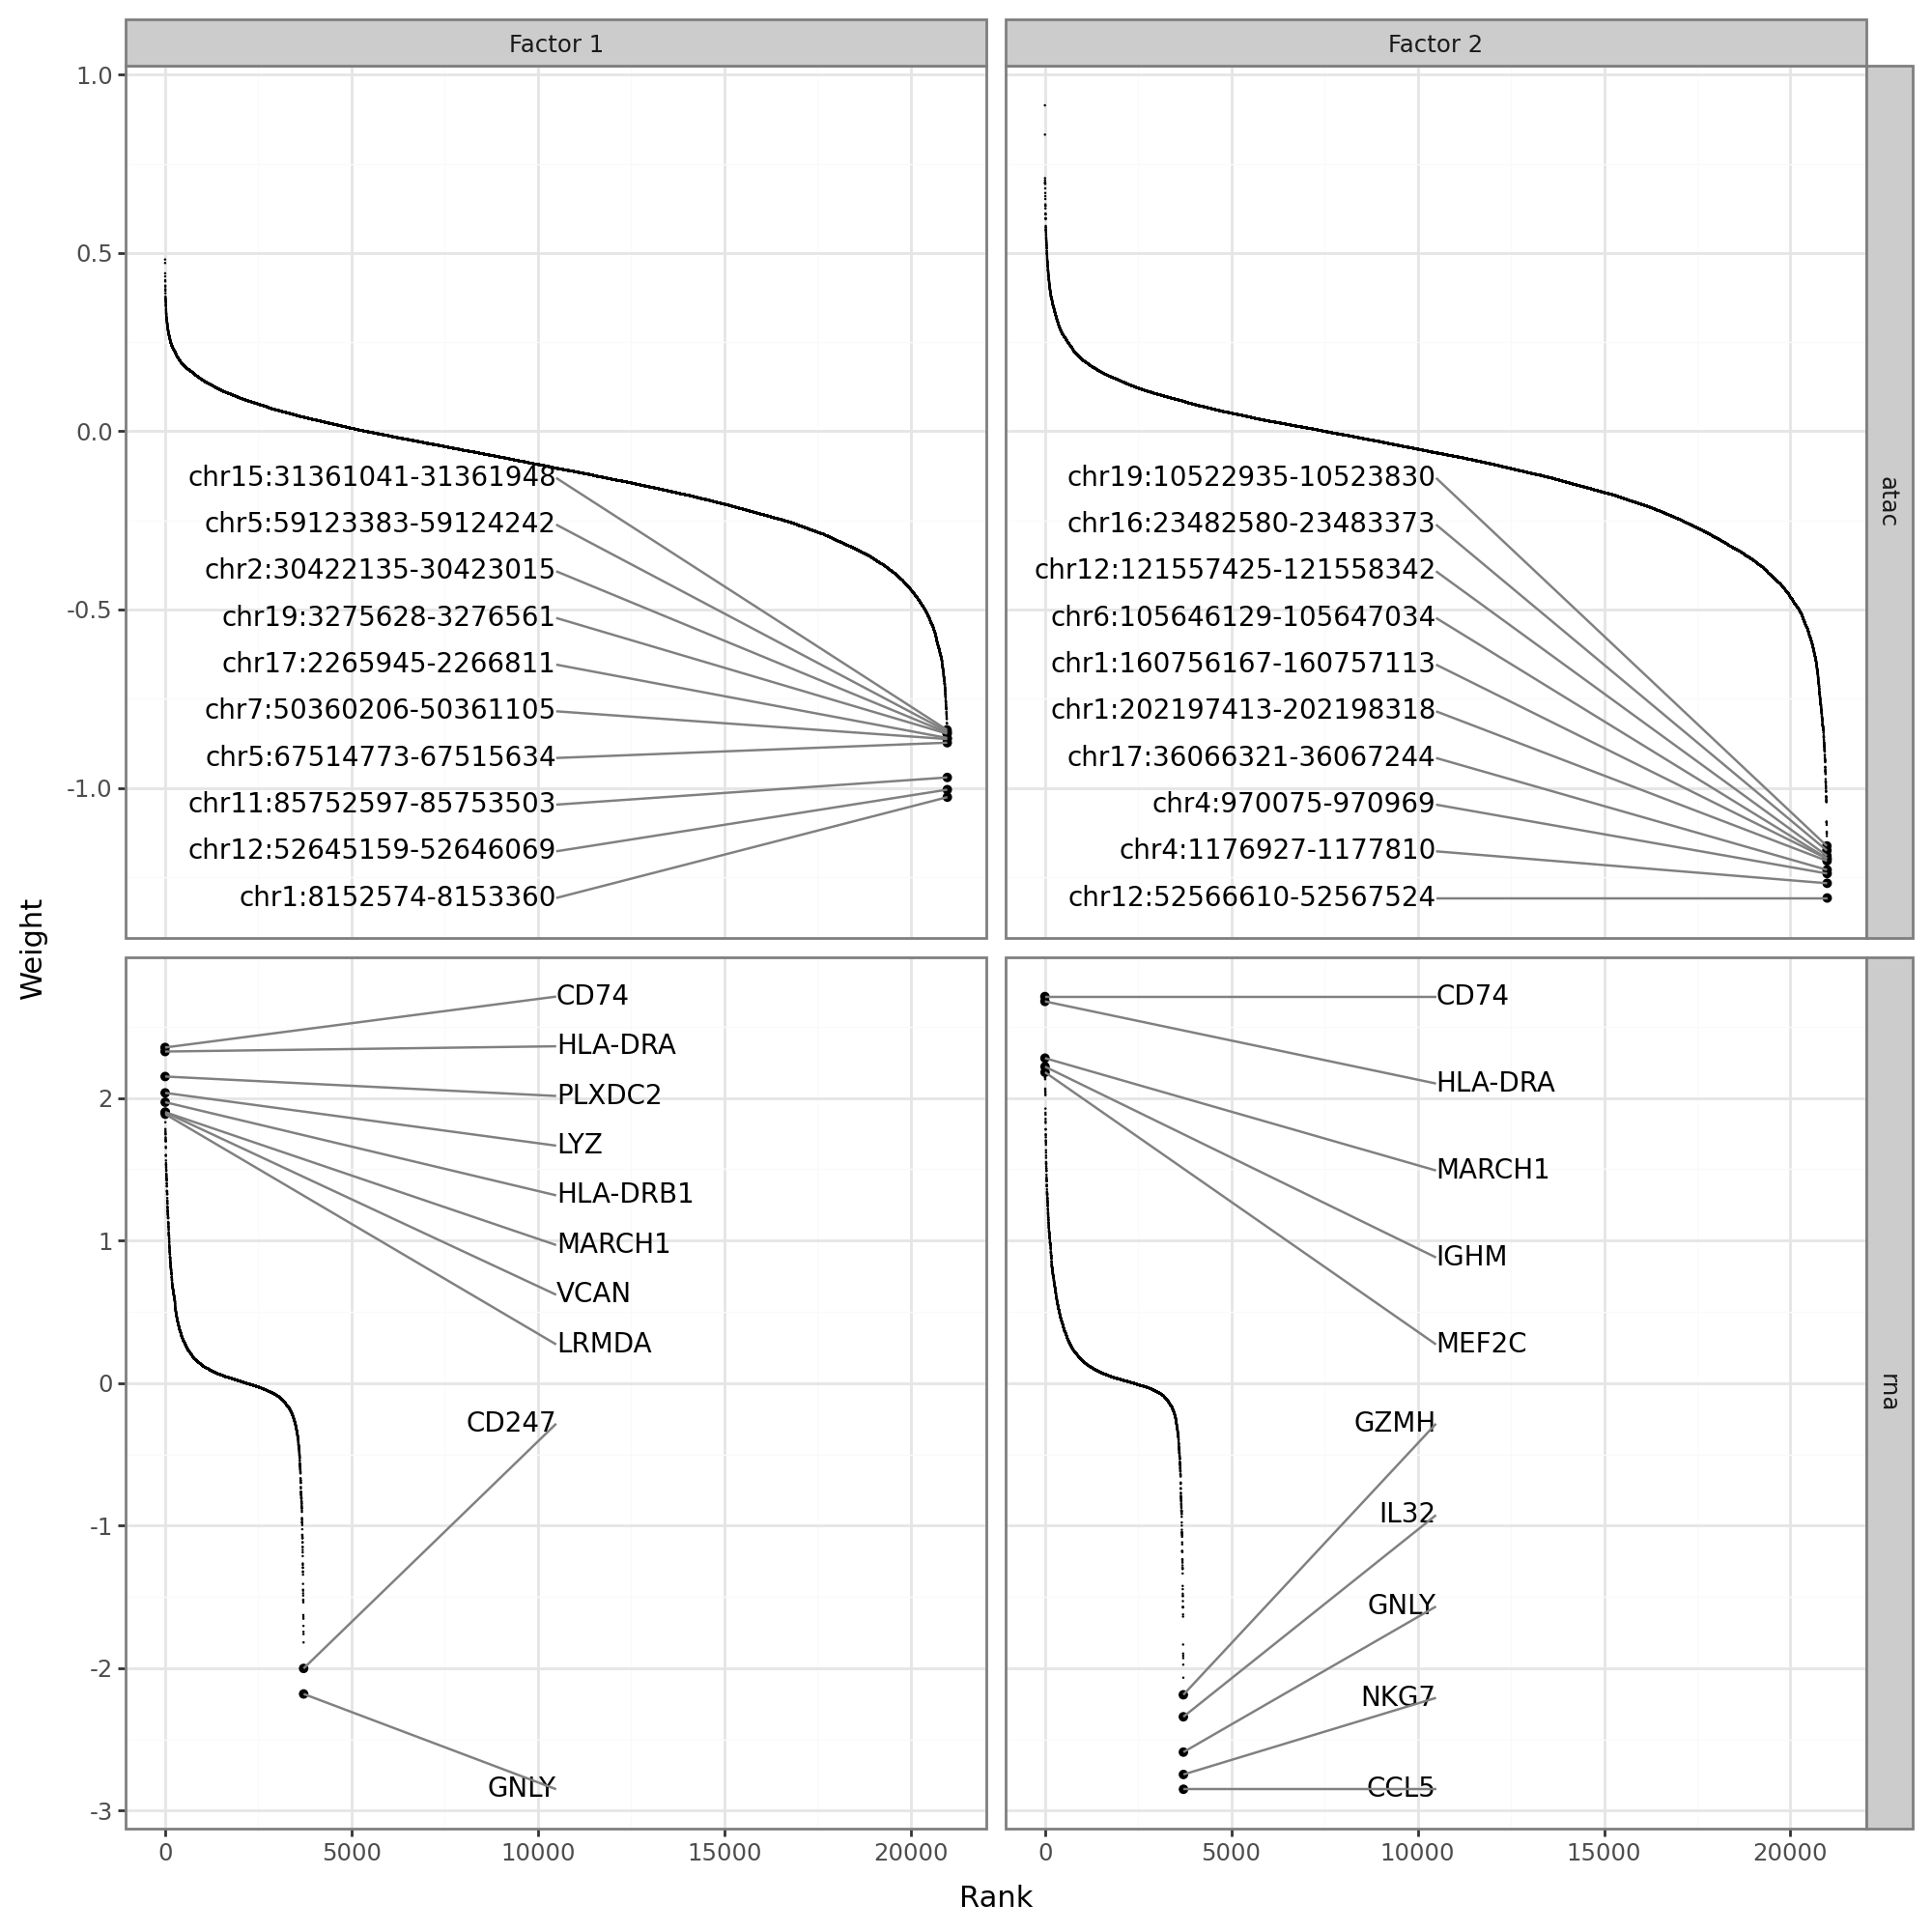

In [15]:
mfl.pl.weights(model, factors=(1, 2), figsize=(10, 10))

We can also plot factors agains each other.
This may be useful to define clusters of cells with similar factor values.

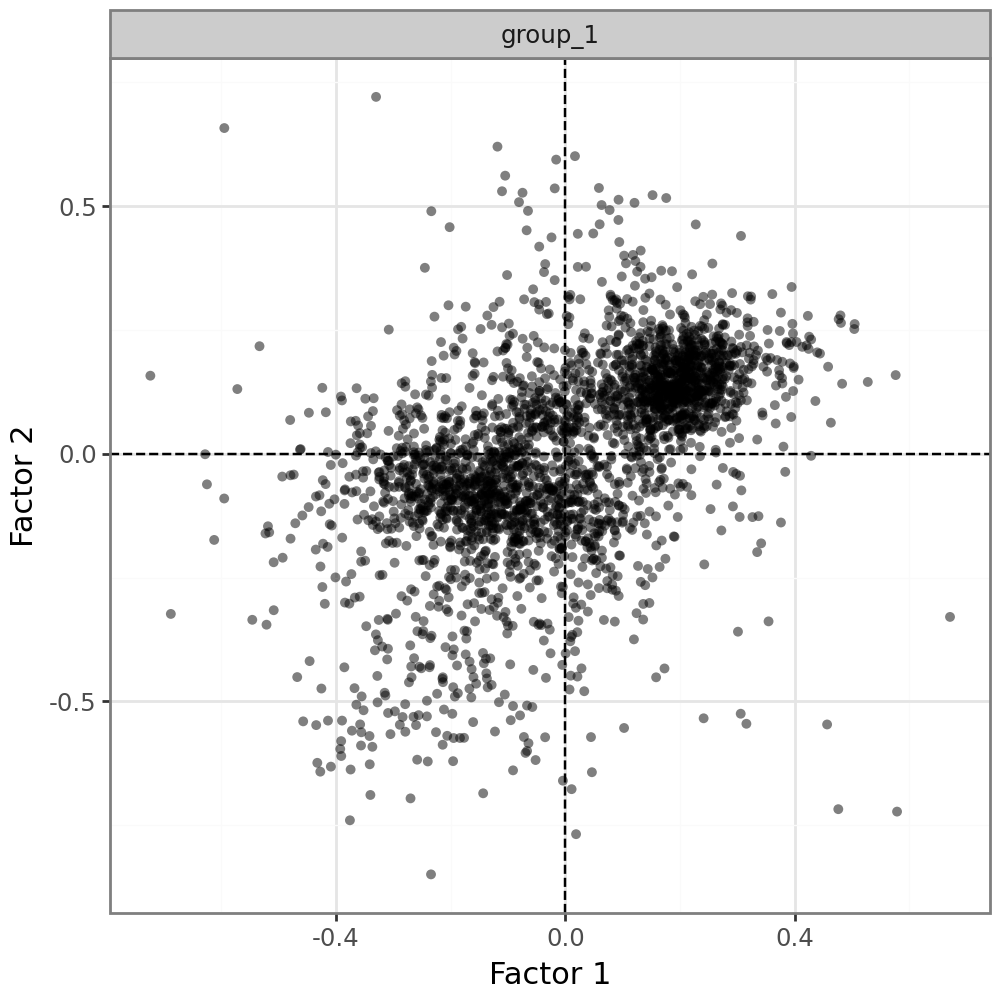

In [16]:
mfl.pl.factors_scatter(model, 1, 2, alpha=0.5)

Of course, MOFA-FLEX does not and cannot provide all imaginable analysis functions.
It thus provides methods to access the factor and weight values, such that they can be used for manual analysis.

In [17]:
weights = model.get_weights()
factors = model.get_factors()

weights["rna"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
ISG15,-0.280046,0.386996,0.269970,-0.051121,-0.030980,-0.793868,-0.405209,0.060351,0.900391,0.165547,-0.646623,0.116404,-0.248874,1.785103,-1.423198
C1orf159,-0.007725,0.162199,-0.102166,0.129365,0.155787,-0.028633,-0.059571,-0.120070,-0.126287,-0.031007,0.007533,0.036689,-0.124093,-0.116410,-0.032022
AL390719.3,-0.035690,0.052736,-0.036267,0.054703,0.041318,-0.001563,0.022349,-0.058472,-0.078257,-0.035999,0.014910,0.062538,0.056413,0.003920,0.001046
TNFRSF18,0.012719,0.228884,-0.005439,-0.645844,0.250172,0.222648,-0.058690,-0.062979,-0.167164,0.116127,-0.094582,-0.578572,0.254038,0.274734,0.043968
TNFRSF4,0.039178,0.393279,-0.063376,-0.647189,0.289181,-0.048226,-0.148442,-0.026147,-0.046146,-0.138628,-0.370098,-0.595252,0.655828,-0.094652,-0.255654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PDZD4,-0.155493,-0.013957,-0.011274,-0.132861,0.150244,0.127063,-0.046707,-0.144145,0.090656,-0.096558,-0.039243,0.163474,0.003551,0.055131,-0.060333
SLC10A3,0.042302,0.055942,-0.017635,-0.078514,-0.022476,0.036513,0.015205,-0.019104,0.014555,0.019694,-0.022694,-0.035630,-0.060869,0.040130,-0.073146
MTCP1,0.123271,-0.117552,0.033291,0.017195,0.000784,0.052957,0.071148,0.055176,-0.078999,0.018382,-0.055674,-0.094594,-0.176269,0.008307,-0.032930
BRCC3,0.346731,-0.201737,0.019094,-0.053000,-0.039264,0.096715,-0.077123,0.106158,0.026418,0.107553,-0.037336,-0.132524,-0.251411,-0.039407,-0.057019


In [18]:
weights["atac"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
chr1:267561-268455,-0.036585,0.018638,-0.018046,0.081911,0.119635,-0.080348,-0.018814,0.084974,-0.090209,-0.038016,0.003527,0.111265,-0.101584,-0.076542,0.009291
chr1:629484-630393,-0.016919,0.128451,0.086286,-0.026709,-0.076011,0.240357,0.286688,0.192265,-0.363926,0.184007,-0.245680,0.196214,-0.135380,-0.090548,-0.096404
chr1:778284-779202,-0.316367,-0.308366,0.024414,-0.179353,-0.099067,0.205049,0.280646,0.110512,0.001027,0.052066,-0.047018,-0.115410,0.331054,-0.047723,0.157502
chr1:844149-845034,-0.140133,-0.152456,-0.296385,0.284019,-0.045109,0.209020,-0.047026,-0.001509,-0.311545,0.124016,-0.121470,-0.058823,0.107831,-0.008960,0.174702
chr1:857873-858632,-0.073183,-0.036833,-0.124901,0.255680,-0.085441,0.100726,0.038123,0.065956,-0.196594,0.088378,0.015242,0.047081,0.094157,-0.087890,-0.140537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GL000219.1:125017-125889,-0.206220,-0.044996,0.084271,-0.032732,-0.064659,-0.111887,0.164214,0.060976,0.038266,0.025803,0.000893,-0.000733,-0.045102,-0.053430,-0.142807
KI270721.1:2089-2980,-0.098098,-0.101169,0.055148,0.029434,0.055505,-0.042897,-0.068903,-0.006993,-0.173510,-0.075282,-0.051041,0.157530,0.182007,-0.111256,-0.018818
KI270726.1:27153-28037,-0.129049,-0.034491,-0.101734,0.041312,-0.132442,0.028711,0.040060,-0.044363,-0.052512,-0.044552,-0.061992,-0.044551,0.056621,-0.061831,0.123549
KI270726.1:41489-42329,0.002653,-0.078327,0.020484,-0.016190,-0.142934,0.125338,0.253716,0.011044,-0.079802,0.056313,0.034112,-0.223072,-0.063103,-0.012337,0.056731


In [19]:
factors["group_1"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,Factor 10,Factor 11,Factor 12,Factor 13,Factor 14,Factor 15
AAACAGCCAAATATCC-1,-0.522988,-0.160842,-0.118435,-0.705156,0.452110,0.337719,-0.274860,-0.108807,0.035058,0.319069,0.365444,0.046002,-0.181184,0.377614,-0.140678
AAACAGCCAGGAACTG-1,0.264425,0.212405,0.055521,0.115924,-0.093405,-0.232308,-0.180916,0.080524,0.183127,-0.035246,0.140071,0.094208,-0.006003,0.361932,-0.038822
AAACAGCCAGGCTTCG-1,0.233191,0.128666,0.215904,0.144812,0.397237,-0.086716,-0.132509,0.257905,0.082476,-0.280018,0.165734,0.007142,-0.145411,-0.040509,0.277436
AAACCAACACCTGCTC-1,0.027248,0.124492,0.263213,-0.492221,-0.612884,-0.063260,0.116697,-0.104273,-0.133189,0.055213,0.197755,0.229622,0.092622,-0.219927,0.332951
AAACCAACAGATTCAT-1,-0.427370,-0.641762,-0.230294,-0.619871,0.093008,-0.013706,-0.120273,0.030533,0.099121,0.071387,0.100890,0.090453,-0.173641,0.213321,0.058430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGTGCATTGTGTG-1,-0.139291,0.046400,-0.167497,0.287187,-0.123500,0.227151,0.223696,0.057324,0.000986,0.106310,0.031385,-0.004964,0.036236,0.069111,0.033046
TTCCCACAGGCGAATA-1,0.156128,0.091431,0.209816,0.083317,0.043535,-0.174329,-0.155113,0.118623,0.073605,-0.089644,0.123221,0.028425,-0.025781,0.218776,0.028817
TTGCTTAGTCCTTTAA-1,0.155808,0.022065,0.168167,0.000366,0.109096,-0.039067,-0.102995,0.087530,0.029195,-0.075530,0.091591,-0.009192,0.028393,0.070915,0.134781
TTGTCCGGTGCATTAG-1,0.157023,0.122303,0.117920,0.049501,0.087144,-0.123051,-0.173307,0.145948,0.050123,-0.127608,0.149784,0.026975,-0.083154,0.119280,0.056124


## Working with multiple additive terms

The general workflow for multiple terms is very similar to the above.
We first assemble a model object from the terms.
Note that when working with multiple terms, each term must get a unique name as its first argument. These names will be used later to identify each term during downstream analysis.

In [20]:
model = mfl.terms.MofaFlex("normal", n_factors=5, weight_prior="Normal") + mfl.terms.MofaFlex("hs", n_factors=5, weight_prior="Horseshoe")

Using several terms with the same name (including the default, which is used if no name is specified) will not work:

In [21]:
model + mfl.terms.MofaFlex("normal", n_factors=3)

ValueError: Operands must have unique term names, but terms normal were found in both operands.

The model can be trained as before.

In [22]:
model.fit(mdata, likelihoods="Normal", plot_data_overview=False, batch_size=1000, seed=42)

INFO	Initializing factors using 'random' method...
INFO	Initializing factors using 'random' method...


  0%|                                                                                                         …

INFO 	 Guessed max_plate_nesting = 3
INFO	Training converged after 1759 epochs.
INFO	Saving results to mofaflex_20260120_121202.h5...


We can still access global properties of the model through the [](#mofaflex.MOFAFLEX) object:

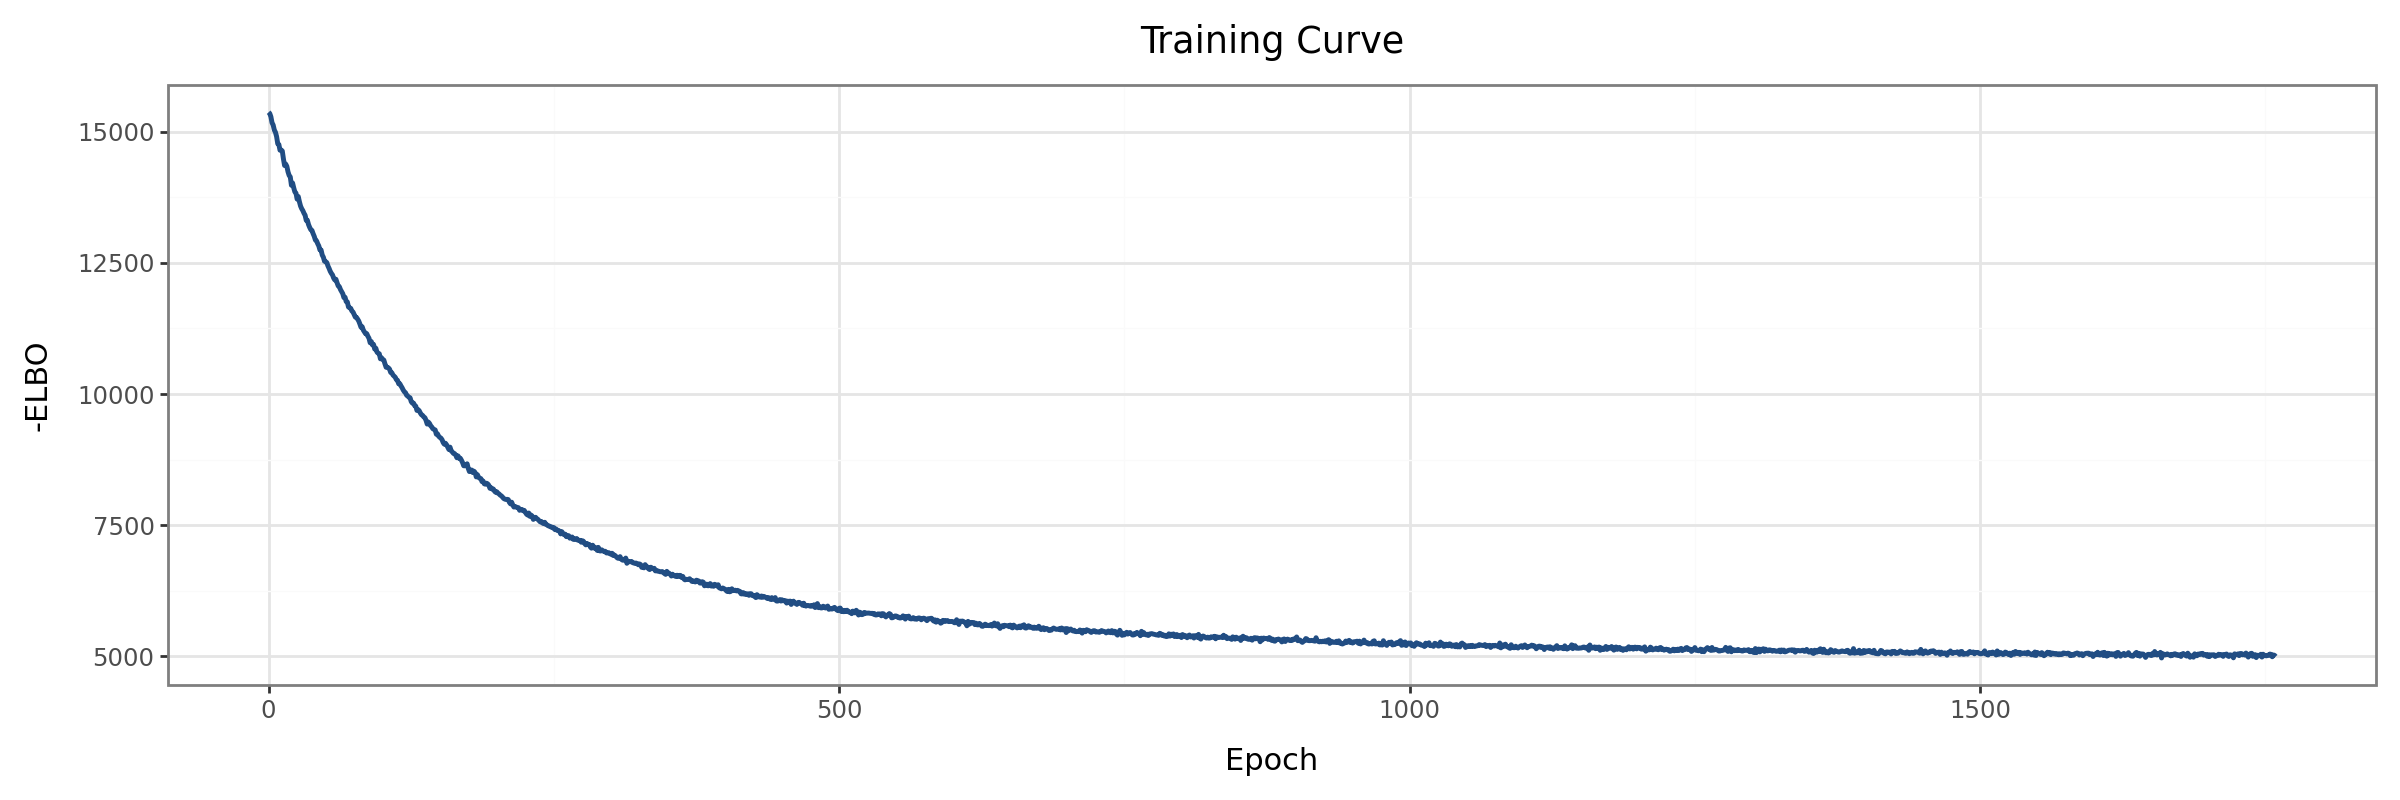

In [23]:
mfl.pl.training_curve(model)

However, each term now has its own set of factors and weights.
Terms can be accessed through `model.terms`.
For example, to plot factor correlations, individual terms need to be passed to the plotting function.

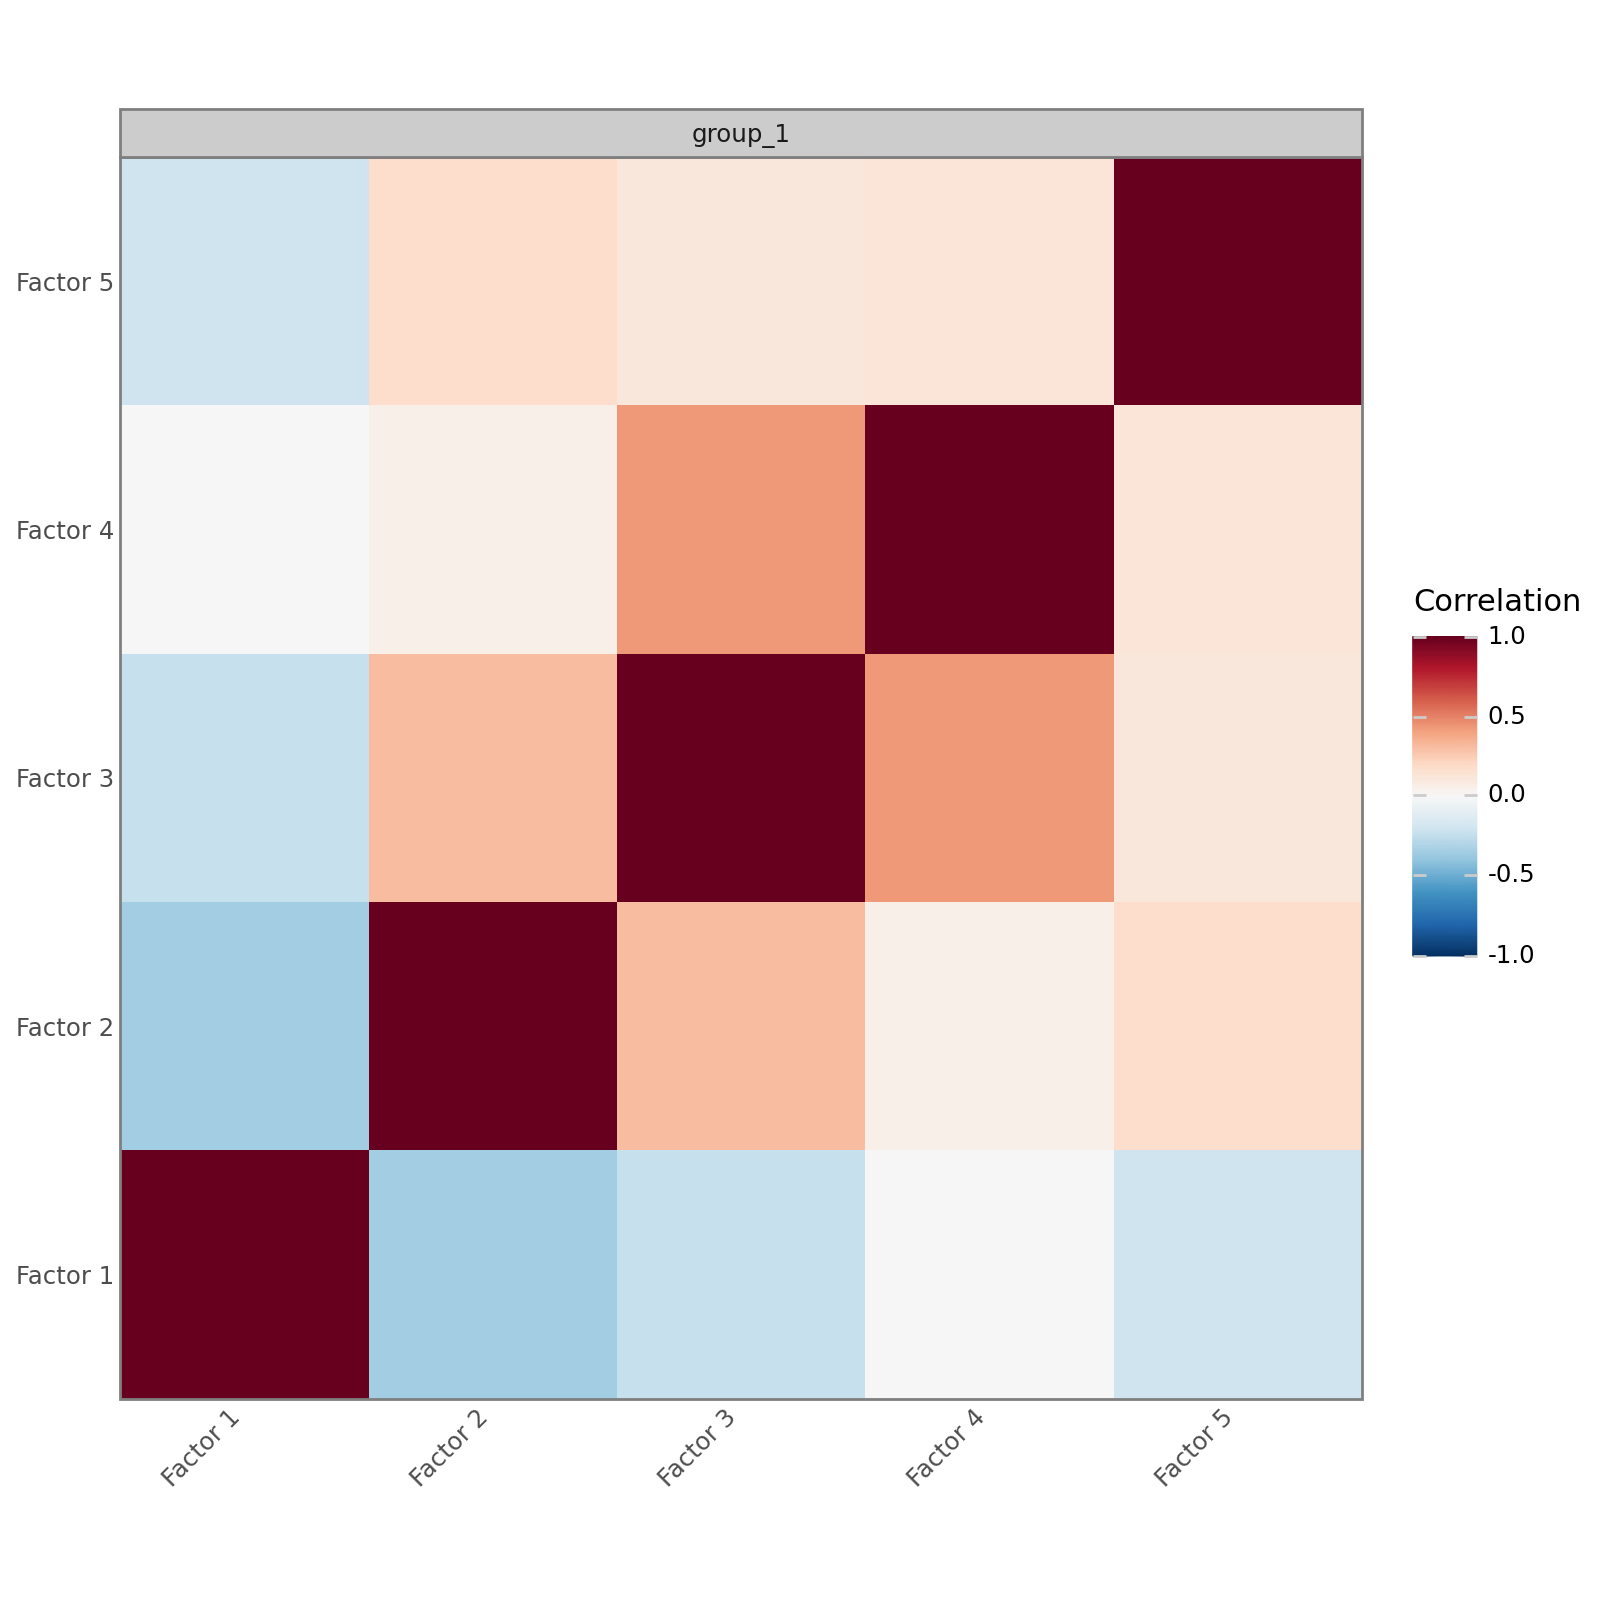

In [24]:
mfl.pl.factor_correlation(model.terms["normal"])

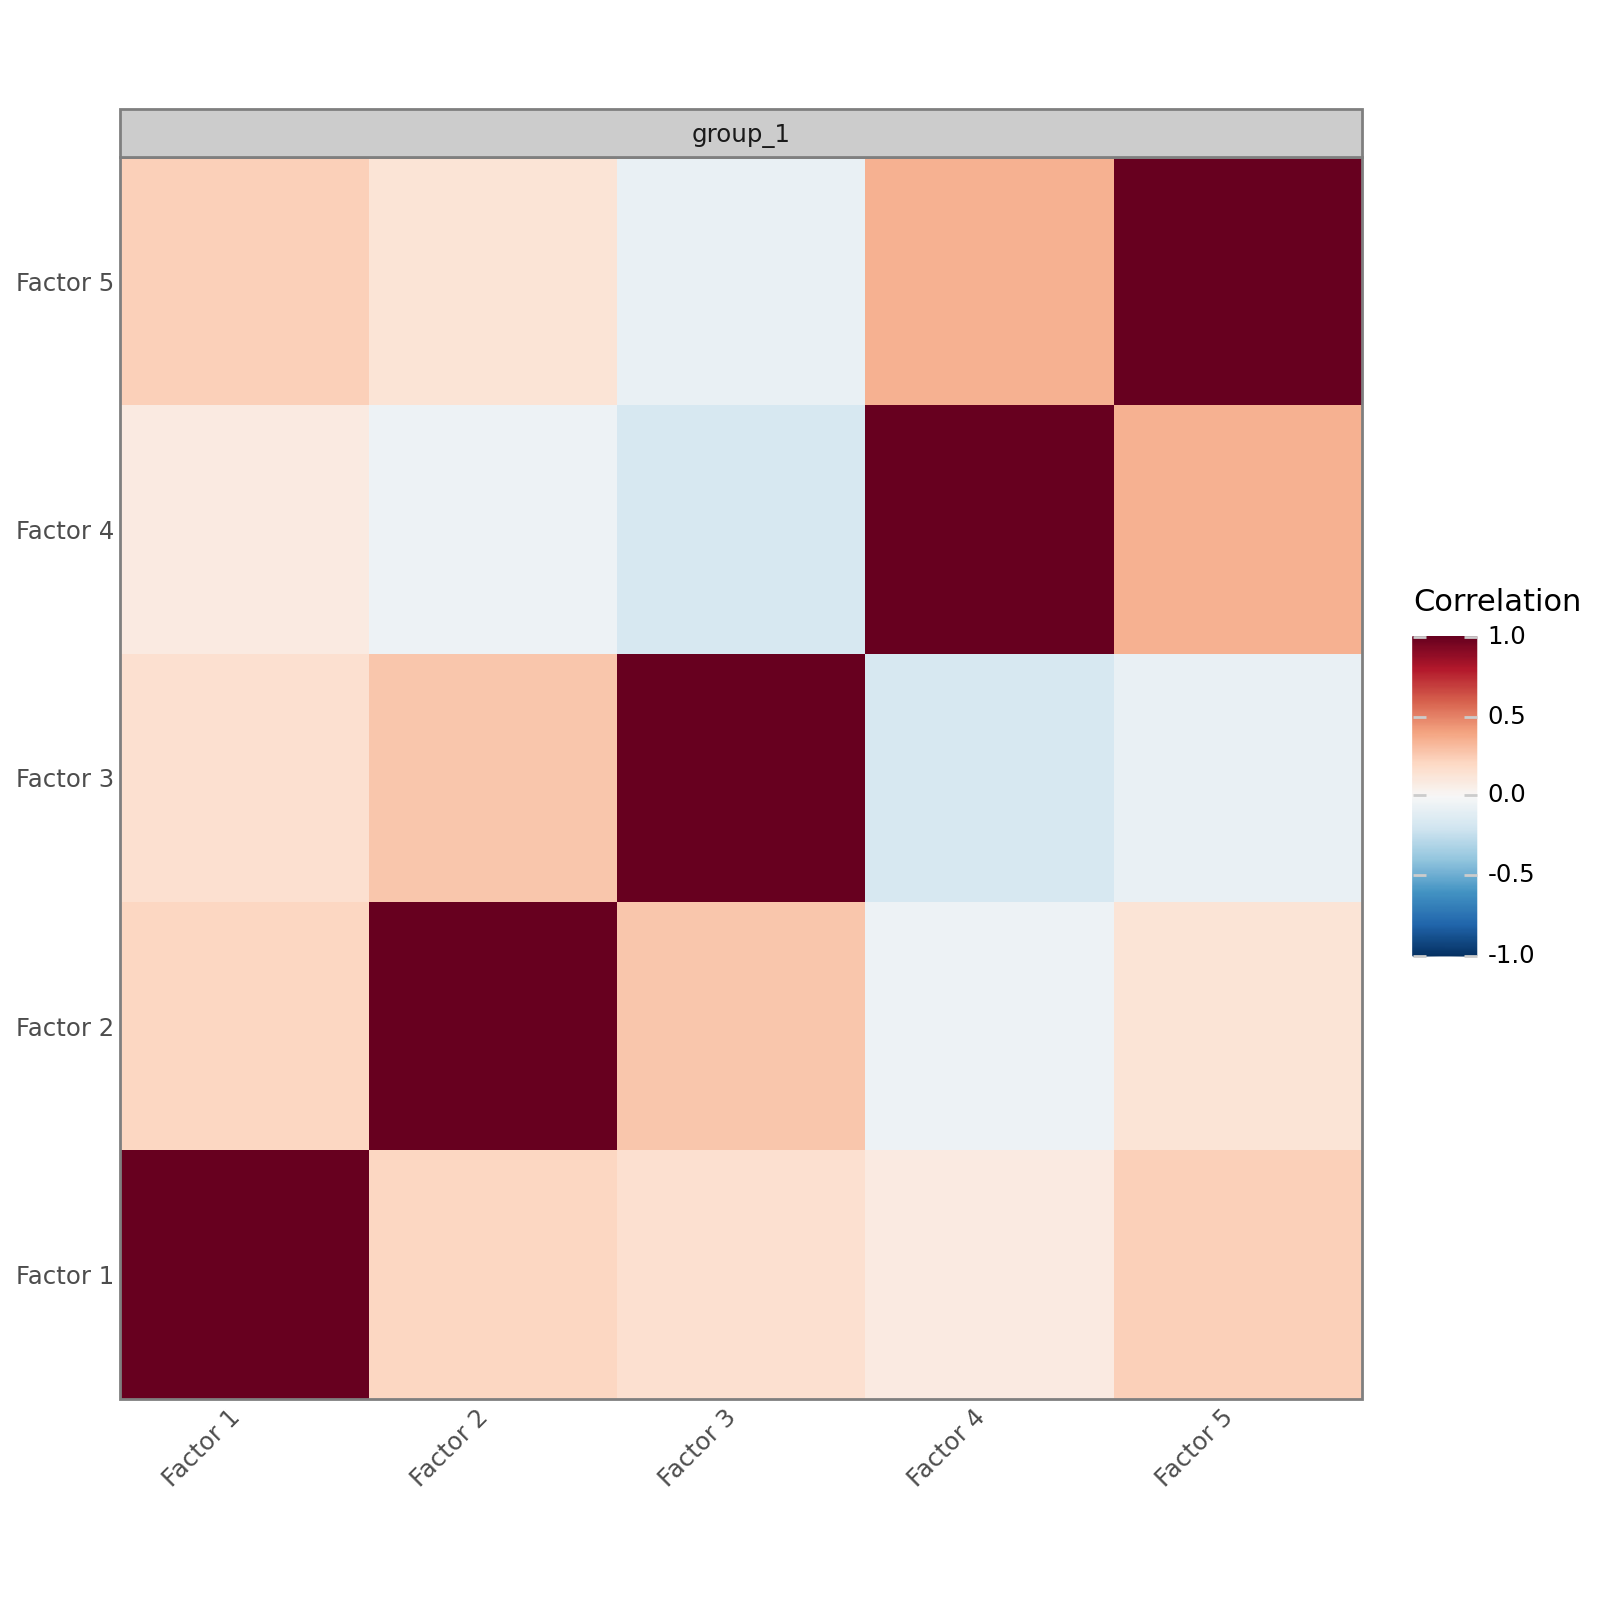

In [25]:
mfl.pl.factor_correlation(model.terms["hs"])

We can retrieve factors and weights from each term individually:

In [26]:
weights = {termname: term.get_weights() for termname, term in model.terms.items()}
model.terms["normal"].get_weights()["rna"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
ISG15,0.580080,-0.302609,-1.131355,0.169371,0.568181
C1orf159,-0.199398,0.088883,-0.202338,0.103569,0.002559
AL390719.3,-0.047300,0.037539,-0.006261,0.029530,0.028305
TNFRSF18,0.269595,0.376351,-0.108663,-0.072438,0.162137
TNFRSF4,0.427565,0.725344,-0.219419,-0.114488,-0.047143
...,...,...,...,...,...
PDZD4,-0.109806,0.018777,-0.015604,0.038678,0.064674
SLC10A3,0.085432,-0.011641,0.029140,0.022183,0.031785
MTCP1,-0.036562,0.009307,0.035378,0.083709,0.018829
BRCC3,0.006611,0.042516,-0.065600,0.139295,-0.019784


In [27]:
model.terms["hs"].get_weights()["atac"]

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5
chr1:267561-268455,-0.005504,-0.002189,0.005756,-0.021523,0.003787
chr1:629484-630393,-0.015807,0.005078,0.047124,-0.009374,-0.002927
chr1:778284-779202,-0.004215,-0.009178,-0.034047,0.072215,0.028681
chr1:844149-845034,-0.010178,0.008360,0.174628,-0.013953,0.009976
chr1:857873-858632,-0.001417,0.025427,0.146733,-0.003949,-0.019507
...,...,...,...,...,...
GL000219.1:125017-125889,-0.014131,-0.008743,0.001121,0.016064,-0.000056
KI270721.1:2089-2980,-0.008382,0.005849,0.005456,-0.004410,0.000807
KI270726.1:27153-28037,-0.013879,0.006763,0.043638,-0.021380,-0.006641
KI270726.1:41489-42329,-0.000796,0.003826,0.014128,-0.017856,0.000562


Adding terms to an already trained model will not work:

In [28]:
model + mfl.terms.MofaFlex(n_factors=6)

ValueError: Cannot add terms to an already trained model.